# GRAPE - Graph Retinal Analysis for Prediction and Evaluation
## Participant: Faran Taimoor Butt

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.1 MB/s eta 0:00:0000:01


In [128]:
import pandas as pd
import numpy as np
import torch
from torch.nn import Linear, Sequential, ReLU, BatchNorm1d
import matplotlib.pyplot as plt
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GINEConv, GPSConv, global_add_pool, GINConv
from torch_geometric.transforms import AddRandomWalkPE
from torch.nn.functional import dropout
from sklearn.preprocessing import StandardScaler
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, roc_auc_score
import seaborn as sns

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

In [5]:
train_df = pd.read_csv('data/public/train_data.csv')
train_df.head(20)

,graph_id,node_id,x,y,width,type,edges
0,D_21,0,165.8,64.8,2.8,1,7;105
1,D_21,1,324.7,77.5,4.0,1,3;10;101;102;107;113
2,D_21,2,333.3,78.7,2.8,1,3;10;101;102;107;109
3,D_21,3,270.7,94.7,2.8,1,1;2
4,D_21,4,244.0,95.8,5.7,1,6;7;9;10;11;18;100;102
5,D_21,5,422.0,97.0,6.3,1,22;111
6,D_21,6,221.3,101.0,2.8,1,4;7;9;11;14;16;18
7,D_21,7,188.3,122.3,6.3,1,0;4;6;11;12;14;15;16;17;19;21;105
8,D_21,8,346.5,125.5,4.5,1,10;13;22;24;30;113
9,D_21,9,255.3,128.7,6.3,1,4;6;10;11;16;18;20


In [6]:
labels_df = pd.read_csv('data/public/train_labels.csv')
labels_df.head(20)

,graph_id,label
0,R_13,1
1,S_1,1
2,R_10,1
3,R_12,1
4,R_14,1
5,D_32,1
6,R_6,1
7,R_15,1
8,R_1,1
9,R_9,1


class distrbution

In [7]:
labels_df['label'].value_counts(normalize=True)

label
0    0.745455
1    0.254545
Name: proportion, dtype: float64

In [8]:
graph_sizes = train_df.groupby('graph_id').size()
graph_sizes.describe()

count     55.000000
mean     257.381818
std      112.157543
min       72.000000
25%      170.500000
50%      233.000000
75%      354.000000
max      468.000000
dtype: float64

In [9]:
s_id = train_df['graph_id'].iloc[0]
s_data = train_df[train_df['graph_id'] == s_id]
s_data

,graph_id,node_id,x,y,width,type,edges
0,D_21,0,165.8,64.8,2.8,1,7;105
1,D_21,1,324.7,77.5,4.0,1,3;10;101;102;107;113
2,D_21,2,333.3,78.7,2.8,1,3;10;101;102;107;109
3,D_21,3,270.7,94.7,2.8,1,1;2
4,D_21,4,244.0,95.8,5.7,1,6;7;9;10;11;18;100;102
...,...,...,...,...,...,...,...
190,D_21,190,185.5,547.0,0.0,0,86;92;93;95;184;189
191,D_21,191,374.0,546.0,2.0,0,96;97;99;193
192,D_21,192,243.0,555.0,2.0,0,95
193,D_21,193,302.0,562.5,0.0,0,94;96;97;191;194


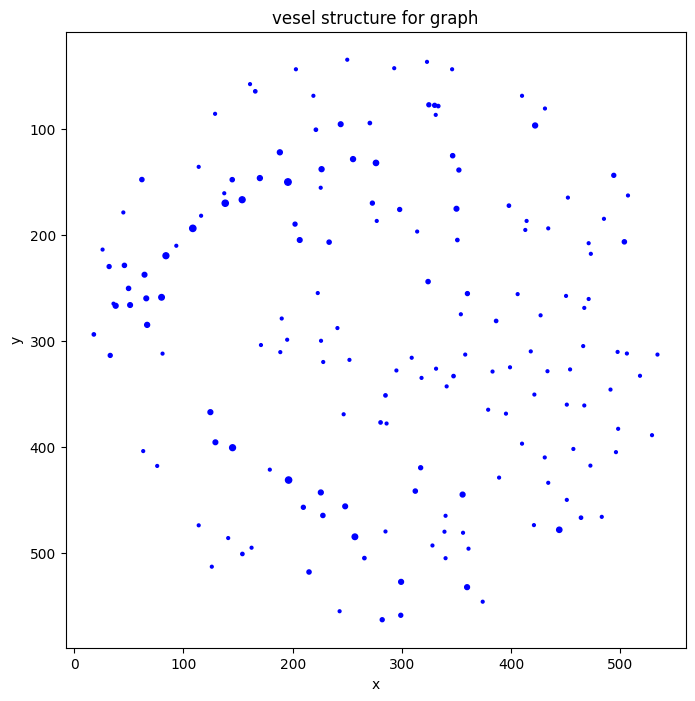

In [10]:
plt.figure(figsize=(8,8))
plt.scatter(s_data['x'],s_data['y'],s=s_data['width']*2,c='blue')
plt.title(f'vesel structure for graph')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().invert_yaxis()
plt.show()

Node Type distribution

In [11]:
train_df['type'].value_counts()

type
0    8191
1    5965
Name: count, dtype: int64

In [12]:
scaler = StandardScaler()

In [13]:
train_df[['x','y','width']] = scaler.fit_transform(train_df[['x','y','width']])
train_df

,graph_id,node_id,x,y,width,type,edges
0,D_21,0,-0.905710,-1.303119,0.473826,1,7;105
1,D_21,1,0.186632,-1.197114,1.137731,1,3;10;101;102;107;113
2,D_21,2,0.245752,-1.187098,0.473826,1,3;10;101;102;107;109
3,D_21,3,-0.184586,-1.053549,0.473826,1,1;2
4,D_21,4,-0.368132,-1.044367,2.078262,1,6;7;9;10;11;18;100;102
...,...,...,...,...,...,...,...
14151,R_15,302,0.044332,1.319457,0.031223,0,80;85;88;297;299
14152,R_15,303,1.027371,1.319457,0.031223,0,NaN
14153,R_15,304,-0.498746,1.348671,0.031223,0,69;78;80;81;83;85;87;89;294;297
14154,R_15,305,1.384839,1.422123,-1.075284,0,70;74


In [14]:
train_df.groupby('graph_id').first().head()

,node_id,x,y,width,type,edges
graph_id,,,,,,
D_21,0,-0.905710,-1.303119,0.473826,1,7;105
D_22,0,-0.095906,-1.485915,0.031223,1,1;3;4;9;11;125;127;128;131;133
D_23,0,0.282873,-1.387422,0.473826,1,42;43
D_24,0,0.031958,-1.311466,0.473826,1,1;3;5;6;8;11;14;168;169;172;179
D_29,0,-0.718726,-1.273905,2.244238,1,2;3;8;10;12;140;141;142;148;149;155;156


# Feature engineering

In [15]:
group  = train_df[train_df['graph_id'] == s_id]
node_feat = torch.tensor(group[['x','y','width','type']].values,dtype=torch.float)

In [16]:
mapping = {orig_id: i for i, orig_id in enumerate(group['node_id'].tolist())}

In [17]:
group

,graph_id,node_id,x,y,width,type,edges
0,D_21,0,-0.905710,-1.303119,0.473826,1,7;105
1,D_21,1,0.186632,-1.197114,1.137731,1,3;10;101;102;107;113
2,D_21,2,0.245752,-1.187098,0.473826,1,3;10;101;102;107;109
3,D_21,3,-0.184586,-1.053549,0.473826,1,1;2
4,D_21,4,-0.368132,-1.044367,2.078262,1,6;7;9;10;11;18;100;102
...,...,...,...,...,...,...,...
190,D_21,190,-0.770284,2.721725,-1.075284,0,86;92;93;95;184;189
191,D_21,191,0.525540,2.713379,0.031223,0,96;97;99;193
192,D_21,192,-0.375006,2.788500,0.031223,0,95
193,D_21,193,0.030583,2.851101,-1.075284,0,94;96;97;191;194


In [18]:
final_edges = [] 

for _, row in group.iterrows():
    src = mapping.get(row['node_id'])
    if src is None or pd.isna(row['edges']):
        continue
    for target in str(row['edges']).split(';'):
        target = target.strip()
        if target:
            target_id = int(target)
            if target_id in mapping:
                dst = mapping[target_id]
                final_edges.append([int(src), int(dst)])

if len(final_edges) > 0:
    edge_index = torch.as_tensor(final_edges).t().contiguous().to(torch.long)
else:
    edge_index = torch.zeros((2, 0), dtype=torch.long)

In [19]:
print(f" edge_index shape = {edge_index.shape}")

 edge_index shape = torch.Size([2, 1192])


In [20]:
all_graphs = []
def create_dataset(df,labels_df,scaler):
    for g_id,group in df.groupby('graph_id'):
        group = train_df[train_df['graph_id'] == g_id]
        x = torch.tensor(group[['x', 'y', 'width', 'type']].values, dtype=torch.float)
        mapping = {orig_id: i for i, orig_id in enumerate(group['node_id'].tolist())}
        final_edges = []
        for _,row in group.iterrows():
            src = mapping.get(row['node_id'])
            if src is None or pd.isna(row['edges']):
                continue
            for target in str(row['edges']).split(';'):
                target = target.strip()
                if target and int(target) in mapping:
                    final_edges.append([int(src), mapping[int(target)]])
        edge_index = torch.as_tensor(final_edges).t().contiguous().to(torch.long) if final_edges else torch.zeros((2, 0), dtype=torch.long)
        label_val = labels_df[labels_df['graph_id'] == g_id].values[0][1]
        y = torch.tensor([label_val],dtype=torch.long)
        all_graphs.append(Data(x=x,edge_index=edge_index,y=y, graph_id=g_id))
create_dataset(train_df,labels_df,scaler)

In [21]:
all_graphs

[Data(x=[195, 4], edge_index=[2, 1192], y=[1], graph_id='D_21'),
 Data(x=[233, 4], edge_index=[2, 1620], y=[1], graph_id='D_22'),
 Data(x=[80, 4], edge_index=[2, 370], y=[1], graph_id='D_23'),
 Data(x=[298, 4], edge_index=[2, 2622], y=[1], graph_id='D_24'),
 Data(x=[260, 4], edge_index=[2, 2274], y=[1], graph_id='D_29'),
 Data(x=[160, 4], edge_index=[2, 964], y=[1], graph_id='D_30'),
 Data(x=[112, 4], edge_index=[2, 540], y=[1], graph_id='D_31'),
 Data(x=[173, 4], edge_index=[2, 1138], y=[1], graph_id='D_32'),
 Data(x=[204, 4], edge_index=[2, 1324], y=[1], graph_id='D_35'),
 Data(x=[203, 4], edge_index=[2, 1464], y=[1], graph_id='D_37'),
 Data(x=[182, 4], edge_index=[2, 1230], y=[1], graph_id='D_38'),
 Data(x=[195, 4], edge_index=[2, 1320], y=[1], graph_id='D_39'),
 Data(x=[458, 4], edge_index=[2, 3792], y=[1], graph_id='H_1'),
 Data(x=[353, 4], edge_index=[2, 2798], y=[1], graph_id='H_11'),
 Data(x=[382, 4], edge_index=[2, 3452], y=[1], graph_id='H_12'),
 Data(x=[376, 4], edge_index=[

In [22]:
print(f"total graphs = {len(all_graphs)}")

total graphs = 55


# GraphSAGE

In [23]:
class GraphSAGE(torch.nn.Module):
    def __init__(self,hidden_channels):
        super(GraphSAGE, self).__init__()
        self.conv1 = SAGEConv(4,hidden_channels)
        self.conv2 = SAGEConv(hidden_channels,hidden_channels)
        self.conv3 = SAGEConv(hidden_channels,hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels,2)
    def forward(self,x,edge_index,batch):
        x = self.conv1(x,edge_index).relu()
        x = F.dropout(x,p=0.5,training=self.training)
        x = self.conv2(x,edge_index).relu()
        x=F.dropout(x,p=0.5,training=self.training)
        x = self.conv3(x,edge_index).relu()
        x = global_mean_pool(x,batch)
        x = dropout(x, p=0.6, training=self.training)
        return self.lin(x)

In [24]:
model = GraphSAGE(16)
model.to(device)

GraphSAGE(
  (conv1): SAGEConv(4, 16, aggr=mean)
  (conv2): SAGEConv(16, 16, aggr=mean)
  (conv3): SAGEConv(16, 16, aggr=mean)
  (lin): Linear(in_features=16, out_features=2, bias=True)
)

In [25]:
weights = torch.tensor([1.0,74.5/25.5]).to(device)
criterion = torch.nn.CrossEntropyLoss(weight = weights)
optimizer = torch.optim.Adam(model.parameters(),lr=0.001, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer,mode='min',factor=0.5,patience=15)

# Data Loading

In [26]:
random.shuffle(all_graphs)
all_graphs[:4]

[Data(x=[153, 4], edge_index=[2, 878], y=[1], graph_id='S_2'),
 Data(x=[294, 4], edge_index=[2, 2408], y=[1], graph_id='H_15'),
 Data(x=[176, 4], edge_index=[2, 1004], y=[1], graph_id='S_139'),
 Data(x=[224, 4], edge_index=[2, 1280], y=[1], graph_id='S_82')]

In [27]:
train_size = int(len(all_graphs) * 0.8)
train_dataset = all_graphs[:train_size]
val_dataset = all_graphs[train_size:]
len(train_dataset),len(val_dataset)

(44, 11)

In [28]:
train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8,shuffle=False)
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

Train size: 44, Val size: 11


In [29]:
def train(model):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out =  model(data.x,data.edge_index,data.batch)
        loss = criterion(out,data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

In [30]:
def test(model,loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())
    return all_preds, all_labels

In [31]:
def get_metrics(preds,labels):
    acc = accuracy_score(labels,preds)
    f1 = f1_score(labels,preds)
    return acc,f1

In [32]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0
for epoch in range(1, 200):
    loss = train(model)
    t_preds, t_labels = test(model, train_loader)
    v_preds, v_labels = test(model, val_loader)
    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    val_f1 = f1_score(v_labels,v_preds,average='weighted')
    scheduler.step(loss)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(),'best_model.pt')
    train_losses.append(loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)
    
    if epoch % 10 == 0:
        curr_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d} train loss = {loss:.4f}  val acc= {v_acc:.2f} Val F1 ={val_f1} LR={curr_lr}")

Epoch 010 train loss = 0.6653  val acc= 0.91 Val F1 =0.8658008658008658 LR=0.001
Epoch 020 train loss = 0.6303  val acc= 0.91 Val F1 =0.8658008658008658 LR=0.001
Epoch 030 train loss = 0.6066  val acc= 0.64 Val F1 =0.712121212121212 LR=0.001
Epoch 040 train loss = 0.5991  val acc= 0.55 Val F1 =0.632034632034632 LR=0.001
Epoch 050 train loss = 0.6491  val acc= 0.64 Val F1 =0.712121212121212 LR=0.001
Epoch 060 train loss = 0.6104  val acc= 0.55 Val F1 =0.632034632034632 LR=0.001
Epoch 070 train loss = 0.6215  val acc= 0.55 Val F1 =0.632034632034632 LR=0.001
Epoch 080 train loss = 0.5602  val acc= 0.55 Val F1 =0.632034632034632 LR=0.001
Epoch 090 train loss = 0.6368  val acc= 0.55 Val F1 =0.632034632034632 LR=0.0005
Epoch 100 train loss = 0.5546  val acc= 0.55 Val F1 =0.632034632034632 LR=0.0005
Epoch 110 train loss = 0.6467  val acc= 0.55 Val F1 =0.632034632034632 LR=0.00025
Epoch 120 train loss = 0.5881  val acc= 0.55 Val F1 =0.632034632034632 LR=0.00025
Epoch 130 train loss = 0.5415  v

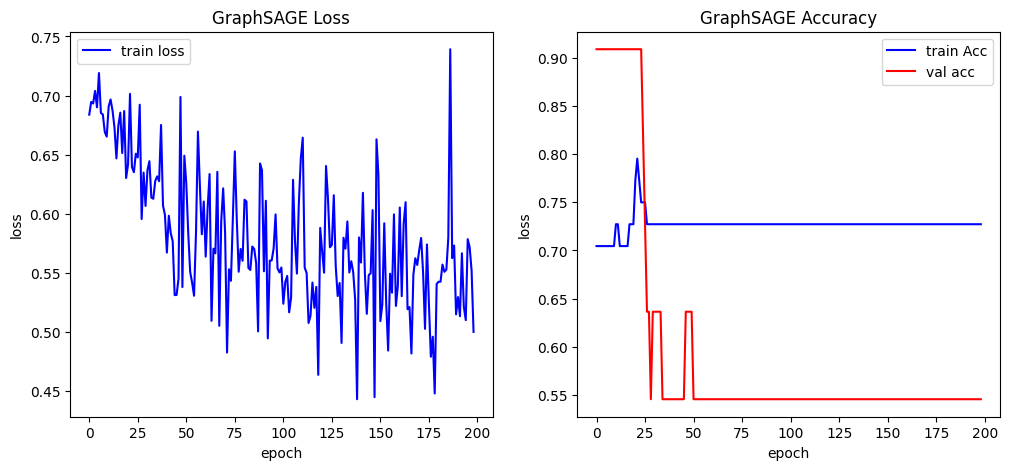

In [33]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train loss', color='blue')
plt.title("GraphSAGE Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train Acc', color='blue')
plt.plot(val_accs, label='val acc', color='red')
plt.title("GraphSAGE Accuracy")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()


In [34]:
model.load_state_dict(torch.load('best_model.pt'))

<All keys matched successfully>

In [35]:
v_preds, v_labels = test(model, val_loader)
print(classification_report(v_labels,v_preds,target_names=["Healthy", "DR"]))

              precision    recall  f1-score   support

     Healthy       0.91      1.00      0.95        10
          DR       0.00      0.00      0.00         1

    accuracy                           0.91        11
   macro avg       0.45      0.50      0.48        11
weighted avg       0.83      0.91      0.87        11



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


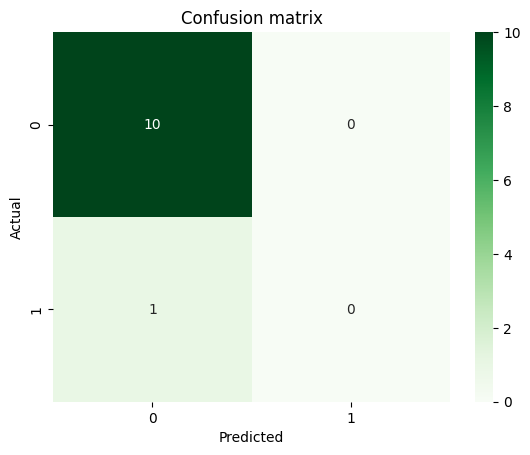

In [36]:
cm = confusion_matrix(v_labels,v_preds)
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.ylabel('Actual')
plt.xlabel("Predicted")
plt.title("Confusion matrix")
plt.show()

# GAT

In [37]:
class GAT(torch.nn.Module):
    def __init__(self,in_channels,hidden_channels,out_channels):
        super(GAT,self).__init__()
        self.conv1 = GATv2Conv(in_channels,hidden_channels, heads=4)
        self.ln1 = LayerNorm(hidden_channels*4)
        self.conv2 = GATv2Conv(hidden_channels*4,hidden_channels,heads=1)
        self.ln2=LayerNorm(hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels,out_channels)
    def forward(self,x,edge_index,batch):
        x = self.conv1(x,edge_index)
        x = self.ln1(x)
        x = F.elu(x)
        x = F.dropout(x,p=0.4,training=self.training)
        x = self.conv2(x,edge_index)
        x=self.ln2(x)
        x=F.elu(x)
        x=global_mean_pool(x,batch)
        x=F.dropout(x,p=0.5,training=self.training)
        return self.lin(x)

In [38]:
model = GAT(in_channels=4,hidden_channels=64,out_channels=2)
model = model.to(device)
model


GAT(
  (conv1): GATv2Conv(4, 64, heads=4)
  (ln1): LayerNorm(256, affine=True, mode=graph)
  (conv2): GATv2Conv(256, 64, heads=1)
  (ln2): LayerNorm(64, affine=True, mode=graph)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)

In [39]:
criterion, weights

(CrossEntropyLoss(), tensor([1.0000, 2.9216]))

In [40]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0
for epoch in range(1, 200):
    loss = train(model)
    t_preds, t_labels = test(model, train_loader)
    v_preds, v_labels = test(model, val_loader)
    t_acc = accuracy_score(t_labels, t_preds)
    v_acc = accuracy_score(v_labels, v_preds)
    val_f1 = f1_score(v_labels,v_preds,average='weighted')
    scheduler.step(loss)
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(),'best_model.pt')
    train_losses.append(loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)
    
    if epoch % 10 == 0:
        curr_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d} train loss = {loss:.4f}  val acc= {v_acc:.2f} Val F1 ={val_f1} LR={curr_lr}")

Epoch 010 train loss = 0.7959  val acc= 0.91 Val F1 =0.8658008658008658 LR=7.8125e-06
Epoch 020 train loss = 0.7127  val acc= 0.91 Val F1 =0.8658008658008658 LR=3.90625e-06
Epoch 030 train loss = 0.6882  val acc= 0.91 Val F1 =0.8658008658008658 LR=3.90625e-06
Epoch 040 train loss = 0.7566  val acc= 0.91 Val F1 =0.8658008658008658 LR=1.953125e-06
Epoch 050 train loss = 0.8062  val acc= 0.91 Val F1 =0.8658008658008658 LR=1.953125e-06
Epoch 060 train loss = 0.7352  val acc= 0.91 Val F1 =0.8658008658008658 LR=9.765625e-07
Epoch 070 train loss = 0.7377  val acc= 0.91 Val F1 =0.8658008658008658 LR=4.8828125e-07
Epoch 080 train loss = 0.7679  val acc= 0.91 Val F1 =0.8658008658008658 LR=4.8828125e-07
Epoch 090 train loss = 0.7587  val acc= 0.91 Val F1 =0.8658008658008658 LR=2.44140625e-07
Epoch 100 train loss = 0.8401  val acc= 0.91 Val F1 =0.8658008658008658 LR=1.220703125e-07
Epoch 110 train loss = 0.7168  val acc= 0.91 Val F1 =0.8658008658008658 LR=1.220703125e-07
Epoch 120 train loss = 0.6

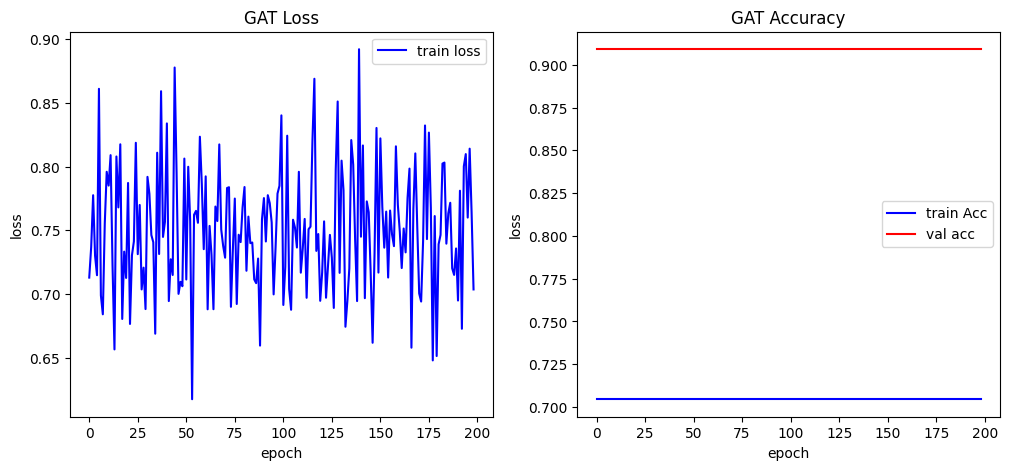

In [41]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='train loss', color='blue')
plt.title("GAT Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='train Acc', color='blue')
plt.plot(val_accs, label='val acc', color='red')
plt.title("GAT Accuracy")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()


              precision    recall  f1-score   support

     Healthy       0.91      1.00      0.95        10
          DR       0.00      0.00      0.00         1

    accuracy                           0.91        11
   macro avg       0.45      0.50      0.48        11
weighted avg       0.83      0.91      0.87        11



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


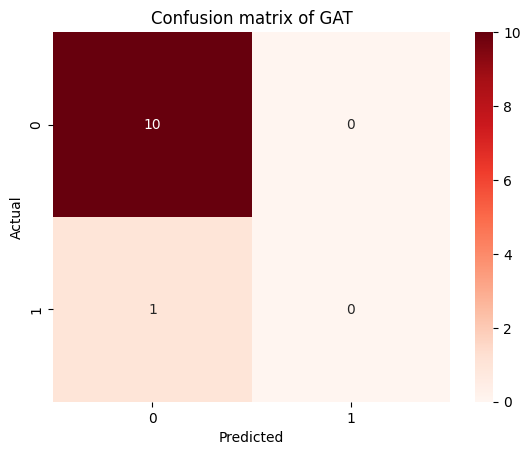

In [42]:
model.load_state_dict(torch.load('best_model.pt'))
v_preds, v_labels = test(model, val_loader)
print(classification_report(v_labels,v_preds,target_names=["Healthy", "DR"]))
cm = confusion_matrix(v_labels,v_preds)
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds')
plt.ylabel('Actual')
plt.xlabel("Predicted")
plt.title("Confusion matrix of GAT")
plt.show()

# Graph Transformer

In [146]:
transform = AddRandomWalkPE(walk_length=16,attr_name='pe')

In [147]:
class GPS(torch.nn.Module):
    def __init__(self,channels, num_layers):
        super().__init__()
        self.node_lin = Linear(4+16,channels)
        self.convs = torch.nn.ModuleList()
        for i in range(num_layers):
            nn = Sequential(
                Linear(channels,channels),
                ReLU(),
                Linear(channels,channels)
            )
            local_conv = GINConv(nn)
            conv = GPSConv(channels, local_conv, heads=4,attn_type='multihead')
            self.convs.append(conv)

        self.mlp = Sequential(
            Linear(channels, channels//2),
            ReLU(),
            Linear(channels // 2, 2)
        )

    def forward(self,x ,pe, edge_index, batch):
        x = torch.cat([x,pe],dim=-1)
        x = self.node_lin(x)

        for conv in self.convs:
            x = conv(x,edge_index,batch)
        x = global_add_pool(x,batch)
        return self.mlp(x)

In [148]:
model = GPS(channels = 64, num_layers=4)
model = model.to(device)

In [149]:
weights,criterion

(tensor([1.0000, 2.9216]), CrossEntropyLoss())

In [150]:
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.pe, data.edge_index, data.batch)
        loss = criterion(out, data.y) 
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

@torch.no_grad()
def test(loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    total_loss = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.pe, data.edge_index, data.batch)
        loss = criterion(out,data.y)
        total_loss += loss.item() * data.num_graphs
        probs = F.softmax(out,dim=1)
        preds = out.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(data.y.cpu())
        all_probs.append(probs[:,1].cpu())
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    y_prob = torch.cat(all_probs).numpy()
    metrics = {
        'loss':total_loss/len(loader.dataset),
        'acc':accuracy_score(y_true,y_pred),
        'macro_f1':f1_score(y_true,y_pred,average='macro'),
        'auc':roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.5
    }
    return metrics

In [183]:
def create_dataset_GPS(df, labels_df=None, mode='train'):
    all_graphs = []
    for g_id, group in df.groupby('graph_id'):
        x = torch.tensor(group[['x', 'y', 'width', 'type']].values, dtype=torch.float)
        mapping = {orig_id: i for i, orig_id in enumerate(group['node_id'].tolist())}
        
        final_edges = []
        for _, row in group.iterrows():
            src = mapping.get(row['node_id'])
            if src is None or pd.isna(row['edges']):
                continue
            for target in str(row['edges']).split(';'):
                target = target.strip()
                if target and target.isdigit():
                    t_idx = int(target)
                    if t_idx in mapping:
                        final_edges.append([int(src), mapping[t_idx]])
        if final_edges:
            edge_index = torch.as_tensor(final_edges).t().contiguous().to(torch.long)
        else:
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            
        if mode == "train":
            label_val = labels_df[labels_df['graph_id'] == g_id].iloc[0, 1]
            y = torch.tensor([label_val], dtype=torch.long)
            data = Data(x=x, edge_index=edge_index, y=y, graph_id=g_id)
        else:
            data = Data(x=x, edge_index=edge_index, graph_id=g_id)
        data = transform(data)
        all_graphs.append(data)
        
    return all_graphs
all_graphs = create_dataset_GPS(train_df, labels_df=labels_df, mode='train')

In [184]:
all_graphs[:3]

[Data(x=[195, 4], edge_index=[2, 1192], y=[1], graph_id='D_21', pe=[195, 16]),
 Data(x=[233, 4], edge_index=[2, 1620], y=[1], graph_id='D_22', pe=[233, 16]),
 Data(x=[80, 4], edge_index=[2, 370], y=[1], graph_id='D_23', pe=[80, 16])]

In [153]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10,min_lr=0.00001)

In [154]:
random.shuffle(all_graphs)
split = int(len(all_graphs) * 0.8)
train_loader = DataLoader(all_graphs[:split],batch_size=16,shuffle=True)
val_loader = DataLoader(all_graphs[split:],batch_size=16,shuffle=False)

In [160]:
history = {'train_loss': [], 'train_macro_f1': [], 'val_macro_f1': [], 'val_auc': []}
best_val_f1 = 0
for epoch in range(1,50):
    train_loss = train()
    train_metrics = test(train_loader)
    val_metrics = test(val_loader)
    scheduler.step(val_metrics['macro_f1'])
    history['train_loss'].append(train_loss)
    history['train_macro_f1'].append(train_metrics['macro_f1'])
    history['val_macro_f1'].append(val_metrics['macro_f1'])
    history['val_auc'].append(val_metrics['auc'])
    print(f"epoch {epoch:03d} loss {train_loss:.4f} val_macro_f1 {val_metrics['macro_f1']:.4f} Val AUC {val_metrics['auc']:.4f}")
    if val_metrics['macro_f1'] > best_val_f1:
        best_val_f1 = val_metrics['macro_f1']
        torch.save(model.state_dict(), 'best_gps_model.pt')

epoch 001 loss 1.8921 val_macro_f1 0.4762 Val AUC 0.2000
epoch 002 loss 1.0637 val_macro_f1 0.4211 Val AUC 0.4000
epoch 003 loss 0.2596 val_macro_f1 0.4211 Val AUC 0.5000
epoch 004 loss 1.4299 val_macro_f1 0.8070 Val AUC 0.9500
epoch 005 loss 0.4923 val_macro_f1 0.6118 Val AUC 0.9500
epoch 006 loss 1.1353 val_macro_f1 0.6944 Val AUC 0.9500
epoch 007 loss 0.0632 val_macro_f1 0.6944 Val AUC 1.0000
epoch 008 loss 0.0242 val_macro_f1 1.0000 Val AUC 1.0000
epoch 009 loss 1.0025 val_macro_f1 1.0000 Val AUC 1.0000
epoch 010 loss 0.0556 val_macro_f1 0.8070 Val AUC 1.0000
epoch 011 loss 0.0413 val_macro_f1 0.8070 Val AUC 1.0000
epoch 012 loss 0.0156 val_macro_f1 0.5417 Val AUC 1.0000
epoch 013 loss 0.0065 val_macro_f1 0.5417 Val AUC 1.0000
epoch 014 loss 0.2403 val_macro_f1 0.6118 Val AUC 1.0000
epoch 015 loss 0.0024 val_macro_f1 0.6118 Val AUC 1.0000
epoch 016 loss 0.0124 val_macro_f1 0.6118 Val AUC 0.9500
epoch 017 loss 0.0113 val_macro_f1 0.5417 Val AUC 0.9500
epoch 018 loss 0.5619 val_macro

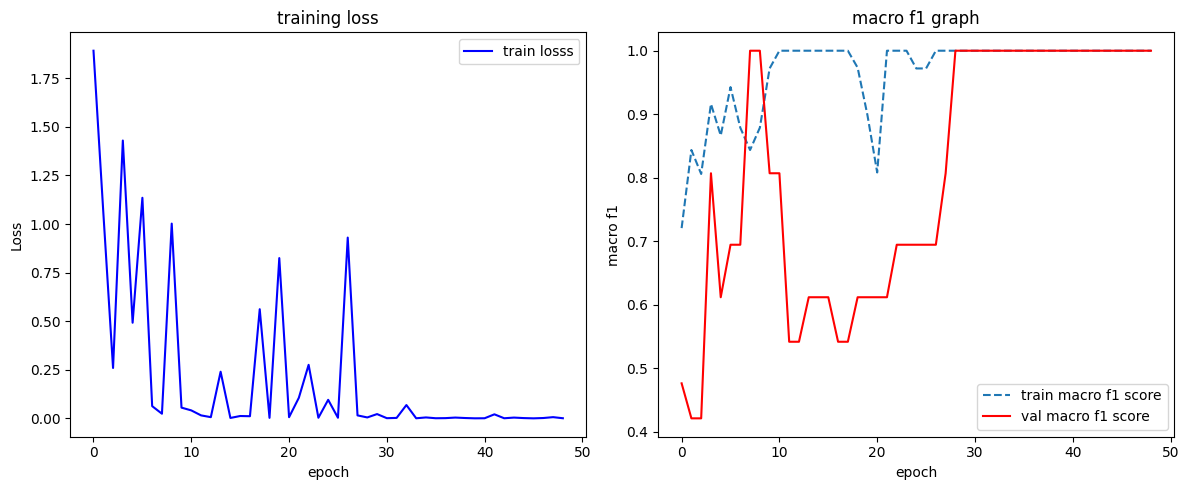

In [162]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train losss', color='blue')
plt.title('training loss')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_macro_f1'], label='train macro f1 score', linestyle='--')
plt.plot(history['val_macro_f1'], label='val macro f1 score', color='red')
plt.title('macro f1 graph')
plt.xlabel('epoch')
plt.ylabel('macro f1')
plt.legend()
plt.tight_layout()
plt.show()

In [188]:
model.load_state_dict(torch.load('best_gps_model.pt'))
model

GPS(
  (node_lin): Linear(in_features=20, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GPSConv(64, conv=GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )), heads=4, attn_type=multihead)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [164]:
@torch.no_grad()
def final_results(loader):
    model.eval()
    y_true, y_pred = [], []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.pe, data.edge_index, data.batch)
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(out.argmax(dim=1).cpu().numpy())
    return y_true, y_pred

In [165]:
true_labels,pred_labels=final_results(val_loader)

In [166]:
print(classification_report(true_labels, pred_labels, target_names=['healthy', "DR"]))

              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        10
          DR       1.00      1.00      1.00         1

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



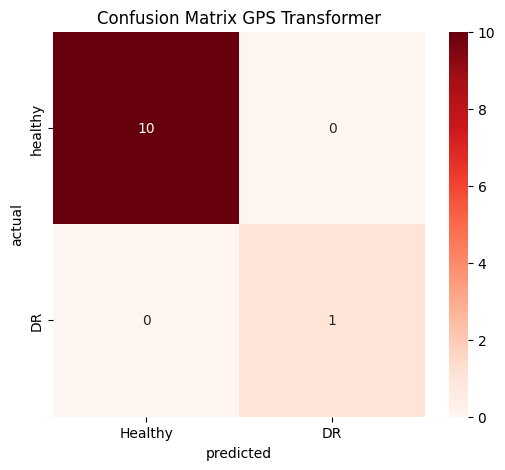

In [167]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(true_labels, pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=["Healthy", "DR"], yticklabels=['healthy','DR'])
plt.title("Confusion Matrix GPS Transformer")
plt.ylabel("actual")
plt.xlabel("predicted")
plt.show()

In [168]:
test_df = pd.read_csv('data/public/test_data.csv')
test_df.head(5)

,graph_id,node_id,x,y,width,type,edges
0,D_25,0,382.7,61.3,6.0,1,3;9;121
1,D_25,1,261.0,77.0,8.2,1,2;4;8;12;13;117;120;125;127;132
2,D_25,2,247.6,86.3,2.0,1,1;4;6;8;12;13;117;120;125;127;132
3,D_25,3,380.7,96.7,8.2,1,0;9;21;118;121;128
4,D_25,4,247.0,103.8,0.0,1,1;2;6;8;12;13;23;117;120;127;132


In [199]:
cols_to_scale = ['x', 'y', 'width']
test_df_scaled = test_df.copy()
test_df_scaled[cols_to_scale] = scaler.transform(test_df[cols_to_scale])
test_graphs = create_dataset_GPS(test_df_scaled, mode='test')
test_graphs

[Data(x=[211, 4], edge_index=[2, 1692], graph_id='D_25', pe=[211, 16]),
 Data(x=[167, 4], edge_index=[2, 1094], graph_id='D_26', pe=[167, 16]),
 Data(x=[238, 4], edge_index=[2, 1638], graph_id='D_27', pe=[238, 16]),
 Data(x=[254, 4], edge_index=[2, 2094], graph_id='D_28', pe=[254, 16]),
 Data(x=[211, 4], edge_index=[2, 1480], graph_id='D_33', pe=[211, 16]),
 Data(x=[179, 4], edge_index=[2, 1152], graph_id='D_34', pe=[179, 16]),
 Data(x=[235, 4], edge_index=[2, 1772], graph_id='D_36', pe=[235, 16]),
 Data(x=[153, 4], edge_index=[2, 898], graph_id='D_40', pe=[153, 16]),
 Data(x=[485, 4], edge_index=[2, 4002], graph_id='H_10', pe=[485, 16]),
 Data(x=[254, 4], edge_index=[2, 900], graph_id='R_2', pe=[254, 16]),
 Data(x=[258, 4], edge_index=[2, 1214], graph_id='R_5', pe=[258, 16]),
 Data(x=[298, 4], edge_index=[2, 1390], graph_id='R_8', pe=[298, 16]),
 Data(x=[178, 4], edge_index=[2, 852], graph_id='S_235', pe=[178, 16]),
 Data(x=[137, 4], edge_index=[2, 750], graph_id='S_240', pe=[137, 16]

In [208]:
model

GPS(
  (node_lin): Linear(in_features=20, out_features=64, bias=True)
  (convs): ModuleList(
    (0-3): 4 x GPSConv(64, conv=GINConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )), heads=4, attn_type=multihead)
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [200]:
model.eval()
test_loader = DataLoader(test_graphs,batch_size=1,shuffle=False)
predictions = {}
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data.x,data.pe,data.edge_index,data.batch)
        pred = out.argmax(dim=1).item()
        predictions[data.graph_id[0]] = pred

In [201]:
predictions

{'D_25': 0,
 'D_26': 0,
 'D_27': 0,
 'D_28': 0,
 'D_33': 0,
 'D_34': 0,
 'D_36': 0,
 'D_40': 0,
 'H_10': 0,
 'R_2': 1,
 'R_5': 1,
 'R_8': 1,
 'S_235': 0,
 'S_240': 0,
 'S_77': 0}

In [204]:
sample_sub = pd.read_csv('data/public/sample_submission.csv')
sample_sub.head()

,graph_id,label
0,D_25,0
1,R_2,0
2,R_8,0
3,D_26,0
4,R_5,0


In [205]:
sample_sub['label'] = sample_sub['graph_id'].map(predictions)

In [206]:
sample_sub

,graph_id,label
0,D_25,0
1,R_2,1
2,R_8,1
3,D_26,0
4,R_5,1
5,S_235,0
6,S_77,0
7,S_240,0
8,D_40,0
9,D_27,0


In [207]:
sample_sub.to_csv('submission.csv', index=False)